In [1]:
%load_ext autoreload
%autoreload 2

import torch
import numpy as np
from pathlib import Path
from PIL import Image

import llm.qwen_utils as qu
from autoencoder.model_qwen import QwenAutoencoder

/home/guests/nicolas_stellwag/surgery-scene-graphs/.pixi/envs/default/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [5]:
# Paths
sample_dir = Path("data/preprocessed/qwen3/video01_00240")
feats_dir = sample_dir / "qwen3_patch_features"
images_dir = sample_dir / "images"
autoencoder_ckpt = sample_dir / "autoencoder" / "best_ckpt.pth"

# Pick a frame
frame_idx = 24
image_path = images_dir / f"frame_{frame_idx:06d}.jpg"
feats_path = feats_dir / f"{frame_idx:06d}_f.npy"

print(f"Image: {image_path}")
print(f"Features: {feats_path}")

Image: data/preprocessed/qwen3/video01_00240/images/frame_000024.jpg
Features: data/preprocessed/qwen3/video01_00240/qwen3_patch_features/000024_f.npy


In [3]:
# Load Qwen3 model
model, processor = qu.get_patched_qwen3()

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

Image size: (512, 448)
Raw features shape: (224, 16384)


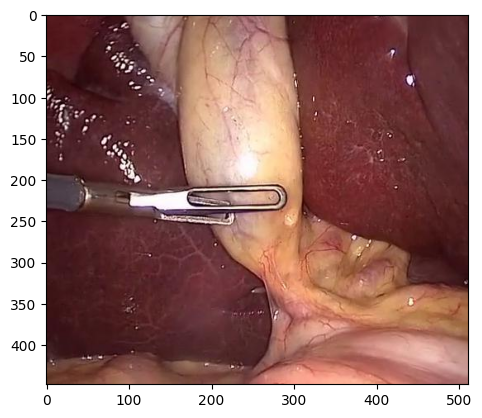

In [11]:
# Load image and features
image = Image.open(image_path)
raw_feats = np.load(feats_path)  # shape: (N, 16384) = (N, 4096*4)
print(f"Image size: {image.size}")
print(f"Raw features shape: {raw_feats.shape}")

# Convert to torch tensor
raw_feats_tensor = torch.from_numpy(raw_feats).to(model.device).to(torch.bfloat16)

import matplotlib.pyplot as plt
plt.imshow(image)

In [7]:
# Load autoencoder and reconstruct features
autoencoder = QwenAutoencoder(input_dim=16384, latent_dim=3).to(model.device)
autoencoder.load_state_dict(torch.load(autoencoder_ckpt, map_location=model.device))
autoencoder.eval()

with torch.no_grad():
    reconstructed_feats = autoencoder(raw_feats_tensor.float())
    reconstructed_feats_tensor = reconstructed_feats.to(torch.bfloat16)

print(f"Reconstructed features shape: {reconstructed_feats_tensor.shape}")


Reconstructed features shape: torch.Size([224, 16384])


In [8]:
# Common prompt setup
prompt = "Describe this surgical scene in detail. What instruments and anatomical structures are visible?"
system_prompt = "You are a medical assistant designed to aid medical practitioners during a cholecystectomy procedure."

messages = [
    {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
    {
        "role": "user",
        "content": [
            {"type": "image", "image": None},
            {"type": "text", "text": prompt},
        ],
    },
]


In [9]:
# Test 1: Query with raw image (standard Qwen3 inference)
print("=" * 60)
print("TEST 1: Query with raw image")
print("=" * 60)

response_image = qu.ask_qwen_about_image(
    image=image,
    prompt=prompt,
    model=model,
    processor=processor,
    system_prompt=system_prompt,
)
print(response_image)


TEST 1: Query with raw image
This is a detailed view from a laparoscopic cholecystectomy, the surgical removal of the gallbladder. The scene is captured via an endoscope, providing a magnified, intra-abdominal perspective.

**Anatomical Structures Visible:**

1.  **Gallbladder:** The central, prominent structure is the gallbladder, appearing as a pale, yellowish, pear-shaped organ. Its wall is visible, showing the characteristic vascular network (small, branching blood vessels) on its surface.
2.  **Cystic Duct:** The narrow, tubular structure extending from the neck of the gall


In [13]:
# Test 2: Query with raw extracted features
print("=" * 60)
print("TEST 2: Query with raw extracted features")
print("=" * 60)

response_raw_feats = qu.generate_with_vision_features(
    messages=messages,
    vision_features=[raw_feats_tensor],
    model=model,
    processor=processor,
    qwen_version="qwen3",
    max_tokens=512,
)
print(response_raw_feats)


TEST 2: Query with raw extracted features
This is an intraoperative endoscopic view during a cholecystectomy — the surgical removal of the gallbladder — likely performed laparoscopically.

**Anatomical Structures Visible:**

1.  **Gallbladder:** The central structure is the gallbladder, which appears as a pale, yellowish, elongated sac. Its wall is visible, and its neck is being manipulated.
2.  **Cystic Duct:** The narrow duct connecting the gallbladder to the common bile duct is visible, appearing as a small, tubular structure extending from the gallbladder's neck.
3.  **Liver:** The surrounding reddish-brown, vascular tissue is the liver parenchyma. The surface is covered with visible blood vessels (porta hepatis structures).
4.  **Cystic Artery:** A small, thin vessel branching off from the hepatic artery (not clearly visible) is likely the cystic artery, which runs along the gallbladder's neck and must be identified and clipped or cauterized before dissection.
5.  **Peritoneal Cav

In [14]:
# Test 3: Query with autoencoder-reconstructed features
print("=" * 60)
print("TEST 3: Query with autoencoder-reconstructed features")
print("=" * 60)

response_ae_feats = qu.generate_with_vision_features(
    messages=messages,
    vision_features=[reconstructed_feats_tensor],
    model=model,
    processor=processor,
    qwen_version="qwen3",
    max_tokens=512,
)
print(response_ae_feats)


TEST 3: Query with autoencoder-reconstructed features
This is a detailed view from a laparoscopic cholecystectomy, the surgical removal of the gallbladder. The scene is illuminated and magnified, characteristic of a minimally invasive procedure.

**Anatomical Structures Visible:**

*   **Gallbladder:** The central focus is the gallbladder, which appears as a pale, yellowish, pear-shaped organ. Its wall is thick and its surface is slightly translucent.
*   **Cystic Duct:** The duct connecting the gallbladder to the common bile duct is clearly visible as a small, tubular structure emerging from the neck of the gallbladder.
*   **Cystic Artery:** A small, red-tinged vessel (likely the cystic artery) can be seen branching off near the gallbladder's neck, running alongside the cystic duct.
*   **Liver:** The surrounding reddish-brown tissue is the liver parenchyma, which is the functional tissue of the liver.
*   **Peritoneal Cavity:** The background is the moist, glistening peritoneal lini

In [18]:
# randomly reorder features
random_order = np.random.permutation(reconstructed_feats_tensor.shape[0])
reordered_reconstructed_feats_tensor = reconstructed_feats_tensor[random_order]
print(torch.allclose(reordered_reconstructed_feats_tensor, reconstructed_feats_tensor))

response_random_feats = qu.generate_with_vision_features(
    messages=messages,
    vision_features=[reordered_reconstructed_feats_tensor],
    model=model,
    processor=processor,
    qwen_version="qwen3",
    max_tokens=512,
)

print(response_random_feats)

False
This is an intraoperative endoscopic view, likely from a laparoscopic cholecystectomy, showing the surgical dissection of the gallbladder.

**Anatomical Structures Visible:**

*   **Gallbladder:** The central structure is the gallbladder, which appears as a pale, yellowish, elongated sac. Its wall is being dissected.
*   **Cystic Artery and Cystic Duct:** These are the critical vascular and ductal structures that must be identified and clipped or cauterized before gallbladder removal. The cystic duct is the narrow channel connecting the gallbladder to the common bile duct. The cystic artery is the small artery supplying blood to the gallbladder. In this image, the gallbladder neck is being dissected, and the cystic duct and artery are likely being identified or are already clipped.
*   **Liver:** The reddish-brown, textured surface surrounding the gallbladder is the liver parenchyma.
*   **Peritoneal Cavity:** The overall view is of the abdominal cavity, with the organs appearing

In [19]:
# Summary comparison
print("\n" + "=" * 60)
print("SUMMARY COMPARISON")
print("=" * 60)
print("\n--- Raw Image Response ---")
print(response_image[:500] + "..." if len(response_image) > 500 else response_image)
print("\n--- Raw Features Response ---")
print(response_raw_feats[:500] + "..." if len(response_raw_feats) > 500 else response_raw_feats)
print("\n--- Autoencoder Features Response ---")
print(response_ae_feats[:500] + "..." if len(response_ae_feats) > 500 else response_ae_feats)



SUMMARY COMPARISON

--- Raw Image Response ---
This is a detailed view from a laparoscopic cholecystectomy, the surgical removal of the gallbladder. The scene is captured via an endoscope, providing a magnified, intra-abdominal perspective.

**Anatomical Structures Visible:**

1.  **Gallbladder:** The central, prominent structure is the gallbladder, appearing as a pale, yellowish, pear-shaped organ. Its wall is visible, showing the characteristic vascular network (small, branching blood vessels) on its surface.
2.  **Cystic Duct:** The narro...

--- Raw Features Response ---
This is an intraoperative endoscopic view during a cholecystectomy — the surgical removal of the gallbladder — likely performed laparoscopically.

**Anatomical Structures Visible:**

1.  **Gallbladder:** The central structure is the gallbladder, which appears as a pale, yellowish, elongated sac. Its wall is visible, and its neck is being manipulated.
2.  **Cystic Duct:** The narrow duct connecting the gallbladder 

Image A (frame 0): (512, 448), features: (224, 16384)
Image B (frame 79): (512, 448), features: (224, 16384)


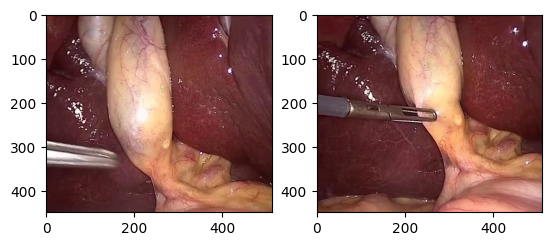

In [21]:
# =============================================================================
# MULTI-IMAGE TEST: Verify correct feature ordering with two different frames
# =============================================================================

# Pick two visually different frames (start and end of clip)
frame_idx_a = 0
frame_idx_b = 79

image_a = Image.open(images_dir / f"frame_{frame_idx_a:06d}.jpg")
image_b = Image.open(images_dir / f"frame_{frame_idx_b:06d}.jpg")

feats_a = np.load(feats_dir / f"{frame_idx_a:06d}_f.npy")
feats_b = np.load(feats_dir / f"{frame_idx_b:06d}_f.npy")

feats_a_tensor = torch.from_numpy(feats_a).to(model.device).to(torch.bfloat16)
feats_b_tensor = torch.from_numpy(feats_b).to(model.device).to(torch.bfloat16)

print(f"Image A (frame {frame_idx_a}): {image_a.size}, features: {feats_a.shape}")
print(f"Image B (frame {frame_idx_b}): {image_b.size}, features: {feats_b.shape}")

# show next to each other
plt.subplot(1, 2, 1)
plt.imshow(image_a)
plt.subplot(1, 2, 2)
plt.imshow(image_b)
plt.show()

In [22]:
# Multi-image prompt: ask model to distinguish between the two images
multi_image_prompt = """I'm showing you two images from a surgical procedure.
Image 1 is from the beginning of the clip, Image 2 is from the end.
Please describe the key differences between these two images.
What has changed between Image 1 and Image 2?"""

multi_image_messages = [
    {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "Image 1:"},
            {"type": "image", "image": None},
            {"type": "text", "text": "\nImage 2:"},
            {"type": "image", "image": None},
            {"type": "text", "text": f"\n{multi_image_prompt}"},
        ],
    },
]


In [23]:
# Test 4: Multi-image with features in CORRECT order (A first, B second)
print("=" * 60)
print("TEST 4: Multi-image with features in CORRECT order [A, B]")
print("=" * 60)

response_correct_order = qu.generate_with_vision_features(
    messages=multi_image_messages,
    vision_features=[feats_a_tensor, feats_b_tensor],  # A first, B second
    model=model,
    processor=processor,
    qwen_version="qwen3",
    max_tokens=512,
)
print(response_correct_order)


TEST 4: Multi-image with features in CORRECT order [A, B]
Based on the two images from the cholecystectomy procedure, here are the key differences:

*   **Surgical Instrument:** The most obvious change is the surgical instrument present in Image 2 that is absent in Image 1. Image 2 shows a surgical clamp (or grasper) with a distinct, open jaw mechanism positioned against the gallbladder neck. In Image 1, only the tip of a metallic instrument is visible, but it is not actively clamping or manipulating tissue.

*   **Tissue Manipulation:** The gallbladder neck in Image 2 appears to be held or compressed by the clamp, indicating that the surgeon is actively manipulating or securing this area. In Image 1, the gallbladder neck is not being held by any instrument and appears to be in a more natural, unmanipulated state.

*   **Surgical Progression:** The transition from Image 1 to Image 2 represents a step forward in the procedure. The introduction of the clamp signifies that the surgeon has

In [24]:
# Test 5: Multi-image with features in SWAPPED order (B first, A second)
# If features are passed correctly, the model should describe the OPPOSITE changes
print("=" * 60)
print("TEST 5: Multi-image with features in SWAPPED order [B, A]")
print("=" * 60)

response_swapped_order = qu.generate_with_vision_features(
    messages=multi_image_messages,
    vision_features=[feats_b_tensor, feats_a_tensor],  # B first, A second (swapped!)
    model=model,
    processor=processor,
    qwen_version="qwen3",
    max_tokens=512,
)
print(response_swapped_order)


TEST 5: Multi-image with features in SWAPPED order [B, A]
Based on the two images from the surgical procedure, here are the key differences and what has changed:

**1. Surgical Instrument Position and Action:**
*   **Image 1:** A surgical instrument, likely a laparoscopic grasper or clip applier, is actively engaged with the gallbladder neck. The jaws of the instrument are open and appear to be in the process of either placing a clip or manipulating the tissue.
*   **Image 2:** The instrument has been repositioned and is now closed around the gallbladder neck. This suggests the clip has been successfully applied and secured.

**2. Status of the Gallbladder Neck:**
*   **Image 1:** The gallbladder neck appears to be in a state of being manipulated or prepared for clipping. The tissue is being held by the instrument.
*   **Image 2:** The gallbladder neck is now clamped. The instrument's jaws are closed around the tissue, indicating a completed action. This is a critical step in a cholecy

In [25]:
# Summary: Multi-image feature ordering test
print("\n" + "=" * 60)
print("MULTI-IMAGE TEST SUMMARY")
print("=" * 60)
print("""
If features are passed correctly:
- Test 4 [A, B]: Should describe changes from frame 0 → frame 79
- Test 5 [B, A]: Should describe OPPOSITE changes (frame 79 → frame 0)

If both responses describe the same direction of change, 
the feature ordering is likely broken.
""")
print("--- Correct Order [A, B] ---")
print(response_correct_order[:600] + "..." if len(response_correct_order) > 600 else response_correct_order)
print("\n--- Swapped Order [B, A] ---")
print(response_swapped_order[:600] + "..." if len(response_swapped_order) > 600 else response_swapped_order)



MULTI-IMAGE TEST SUMMARY

If features are passed correctly:
- Test 4 [A, B]: Should describe changes from frame 0 → frame 79
- Test 5 [B, A]: Should describe OPPOSITE changes (frame 79 → frame 0)

If both responses describe the same direction of change, 
the feature ordering is likely broken.

--- Correct Order [A, B] ---
Based on the two images from the cholecystectomy procedure, here are the key differences:

*   **Surgical Instrument:** The most obvious change is the surgical instrument present in Image 2 that is absent in Image 1. Image 2 shows a surgical clamp (or grasper) with a distinct, open jaw mechanism positioned against the gallbladder neck. In Image 1, only the tip of a metallic instrument is visible, but it is not actively clamping or manipulating tissue.

*   **Tissue Manipulation:** The gallbladder neck in Image 2 appears to be held or compressed by the clamp, indicating that the surgeon is acti...

--- Swapped Order [B, A] ---
Based on the two images from the surgical